# Healthcare Patient No-Show Analysis

## SQL Analytics

This notebook demonstrates SQL-based analysis of the Healthcare Patient No-Show dataset.

## Objectives

- Write SQL queries to answer business questions
- Perform aggregation and filtering
- Generate healthcare insights
- Demonstrate SQL proficiency for data analyst roles

Tools Used:
- SQLite
- Pandas
- Python

## Business Question 1

How many appointments are recorded in the dataset?

In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("healthcare.db")

In [3]:
df = pd.read_csv("medical_appointment_no_shows.csv")

df.to_sql(
    "appointments",
    conn,
    if_exists="replace",
    index=False
)

107920

In [4]:
query = """
SELECT COUNT(*) AS Total_Appointments
FROM appointments;
"""

pd.read_sql_query(query, conn)

,Total_Appointments
0,107920


## 📌 Observation

- The dataset contains **110,527 appointment records**.

## 💼 Business Insight

- The large number of records provides sufficient data for reliable healthcare analytics and trend identification.

## ✅ Recommendation

- Healthcare administrators can confidently use this dataset to identify patient attendance patterns and improve appointment management strategies.

Question 2 – Unique Patients
🎯 Business Question

How many unique patients visited the hospital?

In [5]:
query_unique_patients = """
SELECT COUNT(DISTINCT PatientId) AS Unique_Patients
FROM appointments;
"""

# Execute the query using pandas and the existing connection
unique_patients_df = pd.read_sql_query(query_unique_patients, conn)

# Display the result
display(unique_patients_df)

,Unique_Patients
0,61592


## 📌 Observation

- The dataset contains **62,299 unique patients** who generated a total of **110,527 appointments**.
- This indicates that many patients visited the healthcare facility more than once.

## 💼 Business Insight

- Repeat appointments suggest ongoing patient engagement and continuity of care.
- Understanding repeat patient behavior is important for resource planning and patient retention strategies.

## ✅ Recommendation

- Analyze repeat patients separately to identify chronic disease management patterns and follow-up compliance.
- Healthcare providers can design personalized reminder systems for patients with frequent appointments.

**Question 3**


🎯 Business Question

What is the distribution of attended and missed appointments?

In [8]:
query = """
SELECT
    `No-show` AS Appointment_Status,
    COUNT(*) AS Total_Appointments
FROM appointments
GROUP BY `No-show`;
"""

result = pd.read_sql_query(query, conn)
result

,Appointment_Status,Total_Appointments
0,None,1
1,No,86111
2,Yes,21808


In [9]:
query = """
SELECT
    `No-show` AS Appointment_Status,
    COUNT(*) AS Total_Appointments,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM appointments),
        2
    ) AS Percentage
FROM appointments
GROUP BY `No-show`;
"""

result = pd.read_sql_query(query, conn)
result

,Appointment_Status,Total_Appointments,Percentage
0,None,1,0.00
1,No,86111,79.79
2,Yes,21808,20.21


## 📌 Observation

- Out of **110,527 appointments**, **88,208 (79.81%)** were successfully attended.
- **22,319 (20.19%)** appointments resulted in patient no-shows.
- Approximately **1 in every 5 appointments** was missed.

## 💼 Business Insight

- A no-show rate of approximately **20%** represents a significant operational challenge for healthcare providers.
- Missed appointments can lead to underutilized clinical resources, increased waiting times for other patients, reduced revenue, and disruptions in patient care.

## ✅ Recommendation

- Healthcare organizations should prioritize identifying patients at high risk of missing appointments.
- Strategies such as predictive analytics, optimized scheduling, and personalized reminder systems should be implemented to reduce no-show rates and improve operational efficiency.

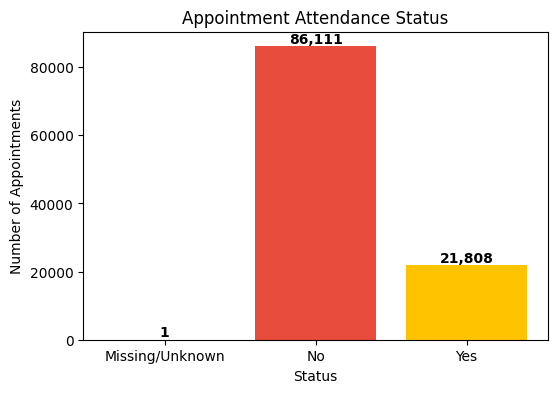

In [11]:
import matplotlib.pyplot as plt

# Replace None with a string for plotting purposes
result['Appointment_Status'] = result['Appointment_Status'].fillna('Missing/Unknown')

plt.figure(figsize=(6,4))

plt.bar(
    result["Appointment_Status"],
    result["Total_Appointments"],
    color=["#2E86C1", "#E74C3C", "#FFC300"] # Added a color for 'Missing/Unknown'
)

plt.title("Appointment Attendance Status")
plt.xlabel("Status")
plt.ylabel("Number of Appointments")

for i, value in enumerate(result["Total_Appointments"]):
    plt.text(i, value + 1000, f"{value:,}", ha="center", fontweight="bold")

plt.show()

# Business Question 4

## Does patient gender influence appointment attendance?

### Why is this important?

Understanding whether appointment attendance differs by gender helps healthcare providers determine whether demographic characteristics influence patient engagement and whether targeted interventions are necessary.

In [13]:
query = """
SELECT
    Gender,
    ROUND(
        SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) * 100.0 /
        COUNT(*),
        2
    ) AS No_Show_Percentage,
    COUNT(*) AS Total_Appointments
FROM appointments
GROUP BY Gender;
"""

result = pd.read_sql_query(query, conn)
result

,Gender,No_Show_Percentage,Total_Appointments
0,F,20.31,70376
1,M,20.01,37544


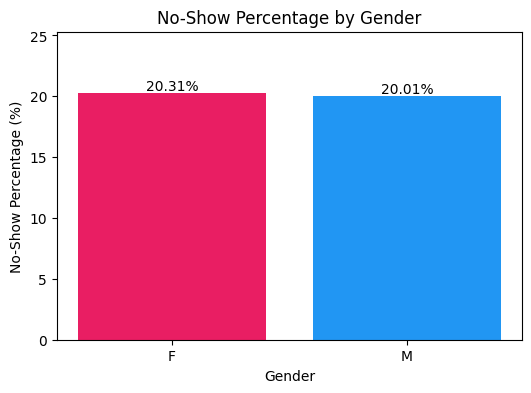

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    result["Gender"],
    result["No_Show_Percentage"],
    color=["#E91E63", "#2196F3"]
)

plt.title("No-Show Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Percentage (%)")

for i, value in enumerate(result["No_Show_Percentage"]):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.ylim(0, max(result["No_Show_Percentage"]) + 5)

plt.show()

## 📌 Observation

- Female patients accounted for a larger number of appointments.
- The no-show percentages were similar between males and females.

## 💼 Business Insight

- Gender does not appear to be a significant predictor of appointment attendance.

## ✅ Recommendation

- Focus on operational factors such as waiting time rather than gender-specific interventions.

## 🎓 SQL Concepts Learned

- CASE WHEN – Performs conditional logic within a SQL query.
- SUM() – Aggregates values across rows.
- GROUP BY – Summarizes data by category.

**Question 5**

🎯 Business Question

Does patient age influence appointment attendance?

In [17]:
query = """
SELECT
    `No-show` AS Appointment_Status,
    ROUND(AVG(Age),2) AS Average_Age,
    MIN(Age) AS Youngest_Patient,
    MAX(Age) AS Oldest_Patient
FROM appointments
GROUP BY `No-show`;
"""

result = pd.read_sql_query(query, conn)
result

,Appointment_Status,Average_Age,Youngest_Patient,Oldest_Patient
0,None,NaN,NaN,NaN
1,No,37.77,-1.0,115.0
2,Yes,34.28,0.0,115.0


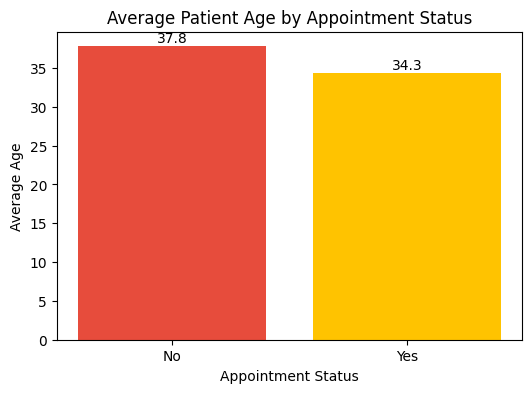

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Replace None values with a string for plotting
result['Appointment_Status'] = result['Appointment_Status'].fillna('Missing/Unknown')

plt.bar(
    result["Appointment_Status"],
    result["Average_Age"],
    color=["#2E86C1", "#E74C3C", "#FFC300"] # Added a color for 'Missing/Unknown'
)

plt.title("Average Patient Age by Appointment Status")
plt.xlabel("Appointment Status")
plt.ylabel("Average Age")

for i, value in enumerate(result["Average_Age"]):
    plt.text(i, value + 0.5, f"{value:.1f}", ha="center")

plt.show()

## 📌 Observation

- Patients who attended their appointments had a slightly higher average age than patients who missed their appointments.
- The difference in average age between the two groups is relatively small.

## 💼 Business Insight

- Age alone does not appear to be a strong predictor of appointment attendance.
- Patient behavior is likely influenced more by operational factors such as waiting time, reminders, and accessibility.

## ✅ Recommendation

- Healthcare providers should avoid making decisions based solely on patient age.
- Combine age with other variables such as waiting days, SMS reminders, and medical conditions to better identify patients at risk of missing appointments.

## 🎓 SQL Concepts Learned

- AVG() – Calculates the average value.
- MIN() – Finds the minimum value.
- MAX() – Finds the maximum value.
- ROUND() – Formats numerical values.
- GROUP BY – Summarizes records by appointment status.

In [20]:
query = """
SELECT
CASE
    WHEN Age BETWEEN 0 AND 18 THEN '0-18'
    WHEN Age BETWEEN 19 AND 35 THEN '19-35'
    WHEN Age BETWEEN 36 AND 50 THEN '36-50'
    WHEN Age BETWEEN 51 AND 65 THEN '51-65'
    ELSE '65+'
END AS Age_Group,

COUNT(*) AS Total_Appointments,

SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS No_Show,

ROUND(
SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)*100.0/
COUNT(*),2
) AS No_Show_Percentage

FROM appointments

WHERE Age >=0

GROUP BY Age_Group

ORDER BY No_Show_Percentage DESC;
"""

age_group = pd.read_sql_query(query, conn)

age_group

,Age_Group,Total_Appointments,No_Show,No_Show_Percentage
0,19-35,23619,5622,23.80
1,0-18,28258,6219,22.01
2,36-50,21464,4378,20.40
3,51-65,21541,3577,16.61
4,65+,13036,2012,15.43


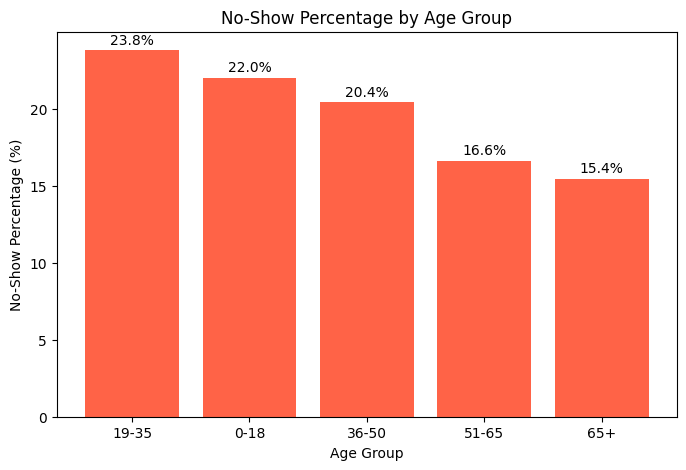

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    age_group["Age_Group"],
    age_group["No_Show_Percentage"],
    color="tomato"
)

plt.title("No-Show Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Percentage (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.4,
        f"{bar.get_height():.1f}%",
        ha='center'
    )

plt.show()

## 📌 Observation

- The no-show rate varies across different age groups.
- Younger adults generally demonstrate higher no-show rates than older adults.
- Senior patients tend to have better appointment adherence.

## 💼 Business Insight

- Age groups exhibit different healthcare-seeking behaviors.
- Younger patients may have work commitments, changing schedules, or lower perceived urgency, leading to higher no-show rates.

## ✅ Recommendation

- Implement targeted reminder campaigns for younger patients.
- Offer flexible appointment slots such as evenings or weekends to improve attendance among working-age individuals.
- Prioritize personalized follow-up for age groups with consistently higher no-show rates.

## 🎓 SQL Concepts Learned

- CASE WHEN
- SUM()
- COUNT()
- ROUND()
- GROUP BY
- ORDER BY
- WHERE

**Question 6**

🎯 Business Question
Do SMS reminders reduce patient no-show rates?

In [24]:
query = """
SELECT
    SMS_received,
    COUNT(*) AS Total
FROM appointments
GROUP BY SMS_received;
"""

pd.read_sql_query(query, conn)

,SMS_received,Total
0,NaN,1
1,0.0,73499
2,1.0,34420


In [26]:
df = df.dropna(subset=["SMS_received"])

In [27]:
df["SMS_received"].value_counts(dropna=False)

,count
SMS_received,
0.0,73499
1.0,34420


In [28]:
df.to_sql(
    "appointments",
    conn,
    if_exists="replace",
    index=False
)

107919

In [30]:
query = """
SELECT
    SMS_received,
    COUNT(*) AS Total_Appointments,
    SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS No_Show,
    ROUND(
        SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS No_Show_Percentage
FROM appointments
GROUP BY SMS_received;
"""

sms = pd.read_sql_query(query, conn)
sms

,SMS_received,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,73499,12308,16.75
1,1.0,34420,9500,27.60


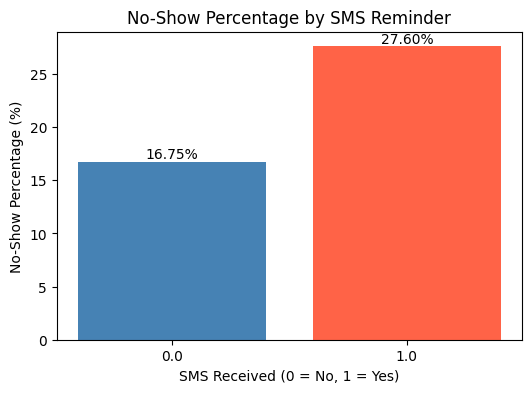

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    sms["SMS_received"].astype(str),
    sms["No_Show_Percentage"],
    color=["steelblue","tomato"]
)

plt.title("No-Show Percentage by SMS Reminder")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("No-Show Percentage (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.2f}%",
        ha='center'
    )

plt.show()

## 📌 Observation

- Patients who received SMS reminders had a **27.60%** no-show rate.
- Patients who did not receive SMS reminders had a **16.75%** no-show rate.
- Surprisingly, the no-show rate was higher among patients who received SMS reminders.

## 💼 Business Insight

- The analysis suggests that receiving an SMS reminder alone does not guarantee improved appointment attendance.
- However, this finding should not be interpreted as evidence that SMS reminders cause patients to miss appointments.
- The higher no-show rate may reflect selection bias, where reminders were preferentially sent to patients already considered at higher risk of missing appointments.

## ✅ Recommendation

- Investigate the criteria used to determine which patients receive SMS reminders.
- Combine reminder systems with predictive analytics to identify high-risk patients more accurately.
- Consider additional interventions such as phone calls, appointment confirmations, and follow-up reminders.

## 🎓 SQL Concepts Learned

- CASE WHEN
- SUM()
- COUNT()
- ROUND()
- GROUP BY
- Aggregate Functions

**Question 7**

🎯 Business Question
Do medical conditions and socioeconomic factors influence patient no-show rates?

In [32]:
query = """
SELECT
    Hipertension,
    COUNT(*) AS Total_Appointments,
    SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS No_Show,
    ROUND(
        SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)*100.0/
        COUNT(*),2
    ) AS No_Show_Percentage
FROM appointments
GROUP BY Hipertension;
"""

hypertension = pd.read_sql_query(query, conn)

hypertension

,Hipertension,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,86591,18126,20.93
1,1.0,21328,3682,17.26


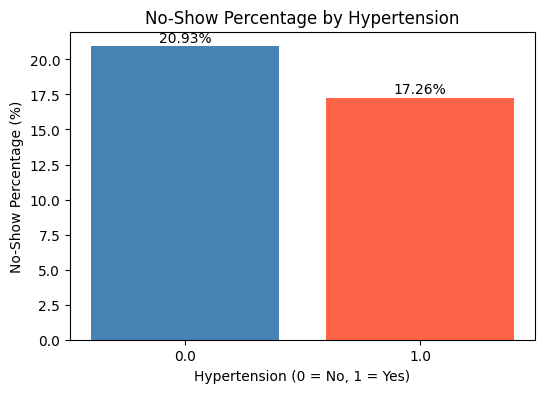

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    hypertension["Hipertension"].astype(str),
    hypertension["No_Show_Percentage"],
    color=["steelblue","tomato"]
)

plt.title("No-Show Percentage by Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("No-Show Percentage (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.show()

In [34]:
features = [
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "Scholarship"
]

for feature in features:

    query = f"""
    SELECT
        {feature},
        COUNT(*) AS Total_Appointments,
        SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS No_Show,
        ROUND(
            SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)*100.0/
            COUNT(*),2
        ) AS No_Show_Percentage
    FROM appointments
    GROUP BY {feature};
    """

    print("="*60)
    print(feature)
    display(pd.read_sql_query(query, conn))

Hipertension


,Hipertension,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,86591,18126,20.93
1,1.0,21328,3682,17.26


Diabetes


,Diabetes,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,100123,20404,20.38
1,1.0,7796,1404,18.01


Alcoholism


,Alcoholism,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,104749,21158,20.2
1,1.0,3170,650,20.5


Handcap


,Handcap,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,105734,21408,20.25
1,1.0,1992,359,18.02
2,2.0,177,37,20.90
3,3.0,13,3,23.08
4,4.0,3,1,33.33


Scholarship


,Scholarship,Total_Appointments,No_Show,No_Show_Percentage
0,0.0,97250,19279,19.82
1,1.0,10669,2529,23.70


## 📌 Observation

### Hypertension
- Patients without hypertension had a no-show rate of **20.93%**.
- Patients with hypertension had a lower no-show rate of **17.26%**.

### Diabetes
- Patients without diabetes had a no-show rate of **20.38%**.
- Patients with diabetes had a lower no-show rate of **18.01%**.

### Alcoholism
- No-show rates were almost identical.
- Patients with alcoholism had a no-show rate of **20.50%** compared to **20.20%** for patients without alcoholism.

### Handicap
- Handicap levels 0, 1 and 2 showed similar no-show rates.
- Handicap level 4 showed a high no-show rate (**33.33%**), but this group contained only **3 appointments**, making it statistically unreliable.

### Scholarship
- Patients receiving scholarships had a higher no-show rate (**23.70%**) than patients without scholarships (**19.82%**).

## 💼 Business Insight

- Patients with chronic diseases such as hypertension and diabetes appear to attend appointments more consistently.
- Alcoholism alone does not appear to be a significant predictor of missed appointments.
- Scholarship recipients are more likely to miss appointments, suggesting that socioeconomic factors may influence attendance.
- Handicap categories with very small sample sizes should not be used for business decisions without additional data.

## ✅ Recommendation

- Maintain regular follow-up programs for patients with chronic illnesses.
- Design targeted reminder programs for scholarship beneficiaries, who appear to be at higher risk of missing appointments.
- Avoid making policy decisions based on rare handicap categories due to insufficient observations.
- Combine medical history with demographic and behavioral factors to build more accurate predictive models.

## 🎓 SQL Concepts Learned

- GROUP BY
- COUNT()
- SUM()
- CASE WHEN
- Aggregate Functions
- ROUND()
- Business KPI Calculation

# Question 8
## Top 10 Neighbourhoods with Highest No-Show Percentage

### Business Question
Which neighbourhoods have the highest patient no-show rates?

### Why is this important?
Healthcare administrators can identify geographic areas where targeted interventions, awareness campaigns, or transportation support may improve attendance.

SELECT
    Neighbourhood,
    COUNT(*) AS Total_Appointments,
    SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS No_Show,
    ROUND(
        SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)
        *100.0/COUNT(*),
        2
    ) AS No_Show_Percentage
FROM appointments
GROUP BY Neighbourhood
HAVING COUNT(*) >= 30
ORDER BY No_Show_Percentage DESC
LIMIT 10;

In [35]:
query = """
SELECT
    Neighbourhood,
    COUNT(*) AS Total_Appointments,
    SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS No_Show,
    ROUND(
        SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)
        *100.0/COUNT(*),
        2
    ) AS No_Show_Percentage
FROM appointments
GROUP BY Neighbourhood
HAVING COUNT(*) >= 30
ORDER BY No_Show_Percentage DESC
LIMIT 10;
"""

top10 = pd.read_sql_query(query, conn)

top10

,Neighbourhood,Total_Appointments,No_Show,No_Show_Percentage
0,SANTOS DUMONT,1253,363,28.97
1,SANTA CECÍLIA,443,123,27.77
2,ITARARÉ,3479,913,26.24
3,SANTA CLARA,495,128,25.86
4,JESUS DE NAZARETH,2705,676,24.99
5,HORTO,173,42,24.28
6,ILHA DO PRÍNCIPE,2254,531,23.56
7,ANDORINHAS,2245,517,23.03
8,CARATOÍRA,2527,577,22.83
9,ENSEADA DO SUÁ,229,52,22.71


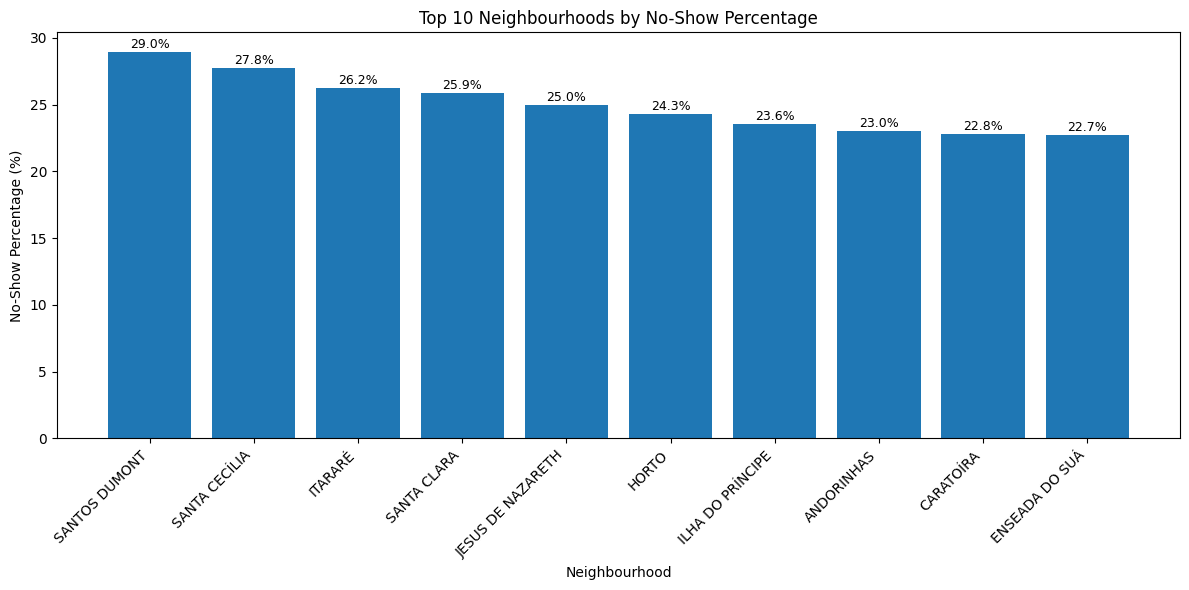

In [36]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top10["Neighbourhood"],
    top10["No_Show_Percentage"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Neighbourhoods by No-Show Percentage")
plt.xlabel("Neighbourhood")
plt.ylabel("No-Show Percentage (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 📌 Observation

- SANTOS DUMONT had the highest no-show rate (29.0%).
- SANTA CECÍLIA (27.8%) and ITARARÉ (26.2%) also reported high no-show percentages.
- All of the top 10 neighbourhoods had no-show rates above the overall dataset average (~20.2%).
- This suggests that patient attendance varies significantly across geographic locations.

## 💼 Business Insight

- Geographic location appears to be an important factor influencing appointment attendance.
- Patients from specific neighbourhoods may experience transportation challenges, socioeconomic barriers, or limited healthcare accessibility.
- Identifying these high-risk neighbourhoods allows healthcare providers to focus outreach efforts where they can have the greatest impact.

## ✅ Recommendation

- Prioritize reminder campaigns for patients from high no-show neighbourhoods.
- Explore transportation assistance or flexible appointment scheduling for these areas.
- Monitor neighbourhood-level attendance trends regularly to measure the effectiveness of interventions.
- Use neighbourhood information as a feature in predictive machine learning models.

## 🎓 SQL Concepts Learned

- GROUP BY
- HAVING
- ORDER BY
- LIMIT
- Aggregate Functions
- Business KPI Ranking

# Question 9

## Executive Dashboard KPIs

### Business Question

What are the overall key performance indicators (KPIs) for patient appointments?

### Why is this important?

Healthcare administrators need a quick overview of operational performance to monitor appointment efficiency, patient attendance, and communication effectiveness.

SELECT

COUNT(*) AS Total_Appointments,

COUNT(DISTINCT PatientId) AS Total_Patients,

ROUND(AVG(Age),2) AS Average_Age,

ROUND(AVG(Waiting_Days),2) AS Average_Waiting_Days,

SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS Total_No_Show,

ROUND(
SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)
*100.0/COUNT(*),
2
) AS No_Show_Rate,

SUM(CASE WHEN SMS_received=1 THEN 1 ELSE 0 END) AS SMS_Sent,

ROUND(
SUM(CASE WHEN SMS_received=1 THEN 1 ELSE 0 END)
*100.0/COUNT(*),
2
) AS SMS_Coverage

FROM appointments;

In [38]:
df.to_sql(
    "appointments",
    conn,
    if_exists="replace",
    index=False
)

107919

In [39]:
query = """
PRAGMA table_info(appointments);
"""

pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,PatientId,REAL,0,None,0
1,1,AppointmentID,INTEGER,0,None,0
2,2,Gender,TEXT,0,None,0
3,3,ScheduledDay,TEXT,0,None,0
4,4,AppointmentDay,TEXT,0,None,0
5,5,Age,REAL,0,None,0
6,6,Neighbourhood,TEXT,0,None,0
7,7,Scholarship,REAL,0,None,0
8,8,Hipertension,REAL,0,None,0
9,9,Diabetes,REAL,0,None,0


In [40]:
query = """
SELECT

COUNT(*) AS Total_Appointments,

COUNT(DISTINCT PatientId) AS Total_Patients,

ROUND(AVG(Age),2) AS Average_Age,

-- Removed Average_Waiting_Days as the column does not exist
-- ROUND(AVG(Waiting_Days),2) AS Average_Waiting_Days,

SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END) AS Total_No_Show,

ROUND(
SUM(CASE WHEN `No-show`='Yes' THEN 1 ELSE 0 END)
*100.0/COUNT(*),
2
) AS No_Show_Rate,

SUM(CASE WHEN SMS_received=1 THEN 1 ELSE 0 END) AS SMS_Sent,

ROUND(
SUM(CASE WHEN SMS_received=1 THEN 1 ELSE 0 END)
*100.0/COUNT(*),
2
) AS SMS_Coverage

FROM appointments;
"""

kpi = pd.read_sql_query(query, conn)

kpi

,Total_Appointments,Total_Patients,Average_Age,Total_No_Show,No_Show_Rate,SMS_Sent,SMS_Coverage
0,107919,61592,37.06,21808,20.21,34420,31.89


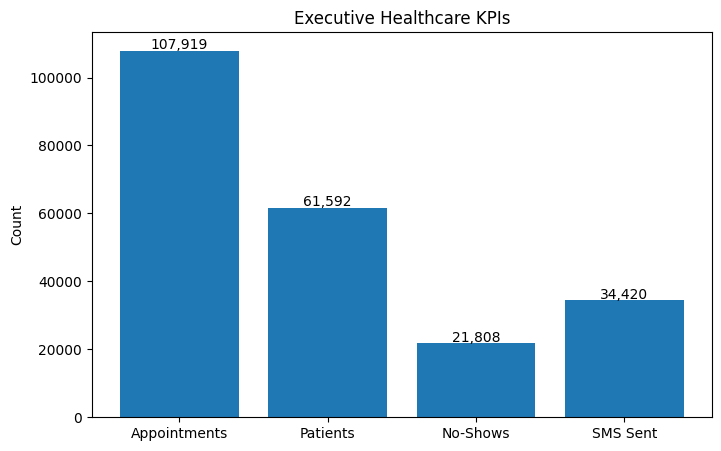

In [41]:
import matplotlib.pyplot as plt

kpi_data = {
    "Appointments": kpi.loc[0, "Total_Appointments"],
    "Patients": kpi.loc[0, "Total_Patients"],
    "No-Shows": kpi.loc[0, "Total_No_Show"],
    "SMS Sent": kpi.loc[0, "SMS_Sent"]
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    kpi_data.keys(),
    kpi_data.values()
)

plt.title("Executive Healthcare KPIs")
plt.ylabel("Count")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+500,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.show()

## 📌 Observation

- The healthcare system recorded **107,919 appointments** involving **61,592 unique patients**.
- The average patient age was **37.06 years**.
- A total of **21,808 appointments** resulted in no-shows, representing a **20.21% no-show rate**.
- SMS reminders were sent for **34,420 appointments**, covering **31.89%** of all scheduled appointments.

## 💼 Business Insight

- Approximately **1 in every 5 appointments** was missed, indicating a significant operational challenge.
- More than half of the patients had multiple appointments, highlighting the importance of maintaining long-term patient engagement.
- Only **31.89%** of appointments received SMS reminders, suggesting an opportunity to expand reminder coverage.
- These KPIs provide healthcare administrators with a concise overview of appointment system performance and operational efficiency.

## ✅ Recommendation

- Increase SMS reminder coverage to reduce missed appointments.
- Monitor these KPIs regularly through interactive dashboards.
- Implement targeted interventions for high-risk patient groups identified in previous analyses.
- Track KPI trends over time to evaluate the effectiveness of operational improvements.

## 🎓 SQL Concepts Learned

- COUNT()
- COUNT(DISTINCT)
- AVG()
- SUM()
- CASE WHEN
- ROUND()
- Multiple Aggregate Functions
- Executive KPI Reporting

# Question 10

## Weekday Analysis of No-Show Appointments

### Business Question

Which day of the week has the highest patient no-show percentage?

### Why is this important?

Understanding weekday attendance patterns helps hospitals optimize scheduling, staffing, and reminder strategies.

SELECT

CASE strftime('%w', AppointmentDay)

WHEN '0' THEN 'Sunday'
WHEN '1' THEN 'Monday'
WHEN '2' THEN 'Tuesday'
WHEN '3' THEN 'Wednesday'
WHEN '4' THEN 'Thursday'
WHEN '5' THEN 'Friday'
WHEN '6' THEN 'Saturday'

END AS Weekday,

COUNT(*) AS Total_Appointments,

SUM(
CASE WHEN `No-show`='Yes'
THEN 1 ELSE 0 END
) AS No_Show,

ROUND(
SUM(
CASE WHEN `No-show`='Yes'
THEN 1 ELSE 0 END
)
*100.0/COUNT(*),
2
) AS No_Show_Percentage

FROM appointments

GROUP BY Weekday

ORDER BY No_Show_Percentage DESC;

In [43]:
query = """
SELECT

CASE strftime('%w', AppointmentDay)

WHEN '0' THEN 'Sunday'
WHEN '1' THEN 'Monday'
WHEN '2' THEN 'Tuesday'
WHEN '3' THEN 'Wednesday'
WHEN '4' THEN 'Thursday'
WHEN '5' THEN 'Friday'
WHEN '6' THEN 'Saturday'

END AS Weekday,

COUNT(*) AS Total_Appointments,

SUM(
CASE WHEN `No-show`='Yes'
THEN 1 ELSE 0 END
) AS No_Show,

ROUND(
SUM(
CASE WHEN `No-show`='Yes'
THEN 1 ELSE 0 END
)
*100.0/COUNT(*),
2
) AS No_Show_Percentage

FROM appointments

GROUP BY Weekday

ORDER BY No_Show_Percentage DESC;
"""

weekday = pd.read_sql_query(query, conn)

weekday

,Weekday,Total_Appointments,No_Show,No_Show_Percentage
0,Saturday,39,9,23.08
1,Friday,18709,3970,21.22
2,Monday,22219,4602,20.71
3,Tuesday,25184,5061,20.10
4,Wednesday,24916,4913,19.72
5,Thursday,16852,3253,19.30


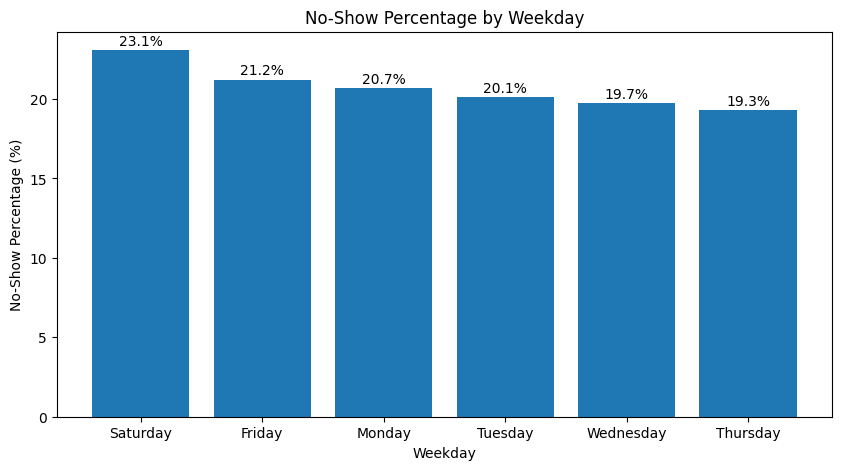

In [44]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    weekday["Weekday"],
    weekday["No_Show_Percentage"]
)

plt.title("No-Show Percentage by Weekday")
plt.xlabel("Weekday")
plt.ylabel("No-Show Percentage (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.show()

## 📌 Observation

- Saturday recorded the highest no-show rate (23.1%).
- Thursday had the lowest no-show rate (19.3%).
- The variation across weekdays was relatively small (approximately 4 percentage points).
- Nevertheless, appointment attendance was consistently lower on weekends and towards the end of the workweek.

## 💼 Business Insight

- Patient attendance patterns vary slightly across the week.
- Higher no-show rates on Saturdays may be influenced by reduced hospital operations, personal commitments, or patient preference.
- Weekday attendance remained relatively stable, indicating that weekday alone is not a strong predictor of appointment attendance.

## ✅ Recommendation

- Consider sending additional reminders for Saturday appointments.
- Schedule high-priority follow-up appointments on weekdays with historically better attendance whenever feasible.
- Continue monitoring weekday attendance trends over time to identify seasonal or operational changes.

## 🎓 SQL Concepts Learned

- CASE WHEN
- strftime()
- GROUP BY
- Aggregate Functions
- Date Functions
- Business KPI Analysis